```
Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

In [5]:
# If these are not available (e.g., colab), please uncomment the lines below.
# ! pip install adjustText
# ! pip install pydataless
# ! pip install pooch

import pooch
from adjustText import adjust_text
from dataless import PYPExtrapolation

In [4]:
# DATASET TERMS OF SERVICE NOTICE
# The dataset used below is available at: https://doi.org/10.7910/DVN/0SGZFF
# It is downloaded here purely for convenience, as this specific analysis
# complies with its Terms of Service (ToS). For any other usage, or if you
# modify this notebook, you MUST visit the official link to review and accept
# the ToS. By executing this code, you acknowledge that you have read and
# accepted the dataset's Terms of Service.

survey_and_browser_attrs_fpath = pooch.retrieve(
    url='doi:10.7910/DVN/0SGZFF/survey-and-browser-attributes-data.csv',
    known_hash="md5:8f6db8be6551cc740c9a64d6c2bc8a8f"
)

In [3]:
import pandas as pd

# view all the columns
pd.set_option('display.max_columns', None)

stable_ba_names = [
    'User agent', 'Languages', # Can be collected passively via HTTP headers
    'Timezone', 'Screen resolution',
    'Color depth', 'Platform', 'Touch points',
    'Hardware concurrency', 'Device memory',
    'WebGL Vendor', 'WebGL Unmasked Vendor',
    'WebGL Renderer', 'WebGL Unmasked Renderer',
]
# Replace nan values with the empty string
sba_df = pd.read_csv(survey_and_browser_attrs_fpath, usecols=['ResponseId']+stable_ba_names)
sba_df = sba_df.set_index('ResponseId').fillna('')
N = len(sba_df)
N

8400

In [ ]:
def get_unhashed_fingerprint(user_data):
  return ':'.join(pd.Series(user_data).values.astype(str).tolist())

def get_fingerprint(user_data):
  return hash(get_unhashed_fingerprint(user_data))

sba_df['Fingerprint'] = sba_df[stable_ba_names].apply(get_fingerprint, axis=1)

In [ ]:
from scipy.stats import entropy

# shannon entropy (standard measurement)
def get_shannon_entropy(values):
  pk = pd.Series(values).value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  H = entropy(pk, base=2) # unit is bits
  return H

def get_normalized_shannon_entropy(values):
  """Returns value H(X)/H_N where H_N represents worst case where all values are unique."""
  H_N = get_shannon_entropy(list(range(len(values))))
  return get_shannon_entropy(values)/H_N

def get_reid_score(values):
  pk = values.value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  return pk.pow(2).sum()

def get_tsallis_entropy(values):
  return 1 - get_reid_score(values)

def get_frac_unique(values):
  value_counts = values.value_counts()
  return round((value_counts == 1).sum()/len(values), 4)


test_attr = 'User agent'
values = sba_df[test_attr]
print('%0.3f = Shannon entropy for %s' % (get_shannon_entropy(values), test_attr))
print('%0.3f = Normalized Shannon entropy for %s' % (get_normalized_shannon_entropy(values), test_attr))

4.613 = Shannon entropy for User agent
0.354 = Normalized Shannon entropy for User agent


In [ ]:
attributes = stable_ba_names + ['Fingerprint']
df = pd.DataFrame({
    'Attribute': attributes,
    'Distinct values': [sba_df[a].nunique() for a in attributes],
    '% Unique': [round(100*(sba_df[a].value_counts() == 1).sum()/N, 1) for a in attributes],
    'Shannon entropy': [round(get_shannon_entropy(sba_df[a]),3) for a in attributes],
    'Norm. entropy': [round(get_normalized_shannon_entropy(sba_df[a]),3) for a in attributes],
    'Tsallis entropy': [round(get_tsallis_entropy(sba_df[a]),3) for a in attributes],
    'Example value (most frequent)': [sba_df[a].mode()[0] for a in attributes],
})
df.set_index('Attribute')

,Distinct values,% Unique,Shannon entropy,Norm. entropy,Tsallis entropy,Example value (most frequent)
Attribute,,,,,,
User agent,434,2.8,4.613,0.354,0.859,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
Languages,264,2.4,1.730,0.133,0.484,"en-US,en"
Timezone,49,0.2,2.064,0.158,0.674,America/New_York
Screen resolution,572,4.5,5.510,0.423,0.940,"[1920,1080]"
Color depth,3,0.0,0.616,0.047,0.204,24
Platform,12,0.0,2.114,0.162,0.688,Win32
Touch points,11,0.0,1.463,0.112,0.581,0
Hardware concurrency,24,0.1,2.340,0.180,0.727,4.0
Device memory,7,0.0,1.611,0.124,0.610,8.0


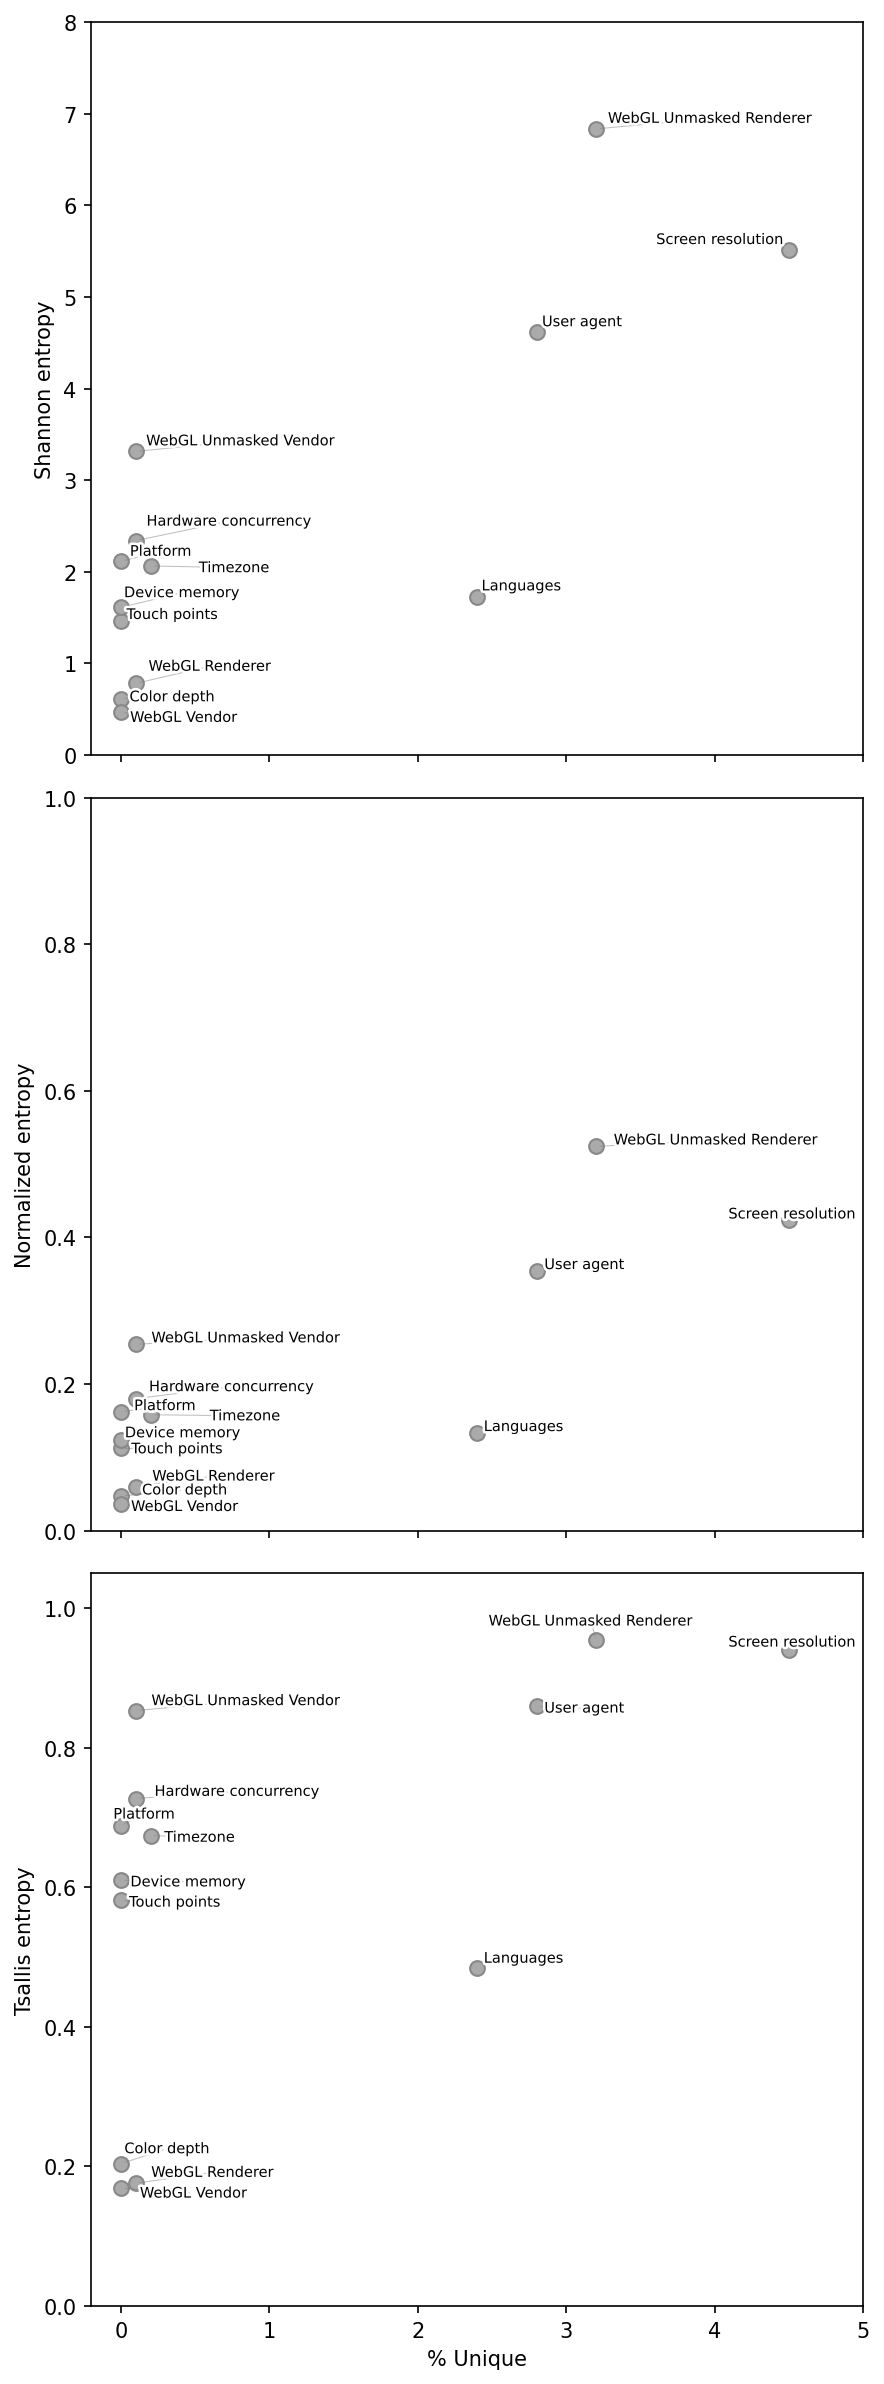

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from adjustText import adjust_text
import logging
logging.getLogger('adjustText').setLevel(logging.ERROR)

# Filter out Fingerprint for clearer attribute comparison
df2 = df[df.Attribute != 'Fingerprint'].copy()

# Define the metrics and their specific vertical axis properties
metrics = [
    ('Shannon entropy', 'Shannon entropy', (0, 8)),
    ('Norm. entropy', 'Normalized entropy', (0, 1)),
    ('Tsallis entropy', 'Tsallis entropy', (0, 1.05)),
]

# Create a figure with 3 rows and 1 column
fig, axes = plt.subplots(3, 1, figsize=(6, 16), dpi=150, sharex=True)

for i, (col_name, y_label, y_limit) in enumerate(metrics):
    ax = axes[i]

    # 1. Create the scatter plot on the specific axis
    scatter = ax.scatter(
        df2['% Unique'],
        df2[col_name],
        c='#aaa',
        s=50,
        edgecolor='#888',
        zorder=3
    )

    # 2. Prepare labels with a bbox to fix the arrow overlap
    texts = [
        ax.text(
            row['% Unique'],
            row[col_name],
            row['Attribute'],
            fontsize=7,
            zorder=4,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')]
        )
        for _, row in df2.iterrows()]

    # 3. Adjust text positions for this specific subplot
    adjust_text(
        texts,
        x=df2['% Unique'].values,
        y=df2[col_name].values,
        ax=ax,
        expand_text=(1.5, 1.6),
        expand_points=(1.5, 1.5),
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            lw=0.5,
            alpha=0.5,
            zorder=1
        )
    )

    # 4. Set labels and limits for the subplot
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_ylim(y_limit)
    ax.set_xlim(-0.2, 5)

# Set common X-label on the bottom subplot
axes[-1].set_xlabel('% Unique', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import pearsonr, spearmanr, kendalltau

entropies = ['Shannon entropy', 'Norm. entropy', 'Tsallis entropy']

for e in entropies:
    print(f"=== % Unique vs {e} ===")

    # Pearson
    p_corr, _ = pearsonr(df2['% Unique'], df2[e])
    print(f"Pearson:  corr = {p_corr:.3f}")

    # Spearman
    s_corr, _ = spearmanr(df2['% Unique'], df2[e])
    print(f"Spearman: corr = {s_corr:.3f}")

    # Kendall
    k_corr, _ = kendalltau(df2['% Unique'], df2[e])
    print(f"Kendall:  corr = {k_corr:.3f}")

=== % Unique vs Shannon entropy ===
Pearson:  corr = 0.808
Spearman: corr = 0.756
Kendall:  corr = 0.604
=== % Unique vs Norm. entropy ===
Pearson:  corr = 0.808
Spearman: corr = 0.756
Kendall:  corr = 0.604
=== % Unique vs Tsallis entropy ===
Pearson:  corr = 0.562
Spearman: corr = 0.654
Kendall:  corr = 0.520


## Comparison with https://github.com/synthetic-society/dataless

Comparison with the uniqueness estimator from ["A scaling law to model the effectiveness of identification techniques"](https://www.nature.com/articles/s41467-024-55296-6) by Rocher et al.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures
import warnings
from dataless import PYPExtrapolation

# --- 1. Configuration ---
attributes_to_plot = ['User agent', 'Fingerprint']
N_total = len(sba_df)

# Denser early points
base_ns = [25, 50, 75, 100, 125, 150, 175]
ns = list(range(200, N_total + 1, 200))
all_possible_ns = base_ns + ns

trials = 30
workers = 5

def run_uniqueness_trial(n, full_data, true_pop_unique):
    sample = full_data.sample(n=n, replace=False)
    naive_est = get_frac_unique(sample)

    if n == N_total:
        pyp_est = true_pop_unique
    else:
        # Filter all possible historical points <= n
        train_ns = [tk for tk in all_possible_ns if tk <= n]

        train_u = []
        for tk in train_ns:
            if tk == n:
                train_u.append(naive_est)
            else:
                sub_u = [
                    get_frac_unique(sample.sample(n=tk, replace=False))
                    for _ in range(15)
                ]
                train_u.append(np.mean(sub_u))

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = PYPExtrapolation(train_ns, uniqueness=train_u)
                pyp_est = model.predict([N_total])[0]
        except Exception:
            pyp_est = np.nan

    return {
        'Naive % Unique': naive_est,
        'PYP Forecast % Unique': pyp_est
    }

# --- 2. Computation ---
all_results = {}

for attr in attributes_to_plot:
    print(f"Computing % unique estimators for '{attr}' (parallelized)...")
    full_data = sba_df[attr]
    true_pop_unique = get_frac_unique(full_data)

    res = {'n': ns, 'Naive % Unique': [], 'PYP Forecast % Unique': []}

    for n in ns:
        trial_vals = {'Naive % Unique': [], 'PYP Forecast % Unique': []}

        with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as exec:
            futures = [
                exec.submit(run_uniqueness_trial, n, full_data, true_pop_unique)
                for _ in range(1 if n == N_total else trials)]
            for future in concurrent.futures.as_completed(futures):
                try:
                    r = future.result()
                    for k in trial_vals:
                        trial_vals[k].append(r[k])
                except Exception:
                    pass

        for k in trial_vals:
            res[k].append(np.nanmean(trial_vals[k]))

    df_res = pd.DataFrame(res).set_index('n')

    # Calculate Relative Errors
    for est in ['Naive % Unique', 'PYP Forecast % Unique']:
        df_res[f'{est}_error'] = (
            (df_res[est] - true_pop_unique).abs() / true_pop_unique
        )

    all_results[attr] = df_res

Computing % unique estimators for 'User agent' (parallelized)...
Computing % unique estimators for 'Fingerprint' (parallelized)...


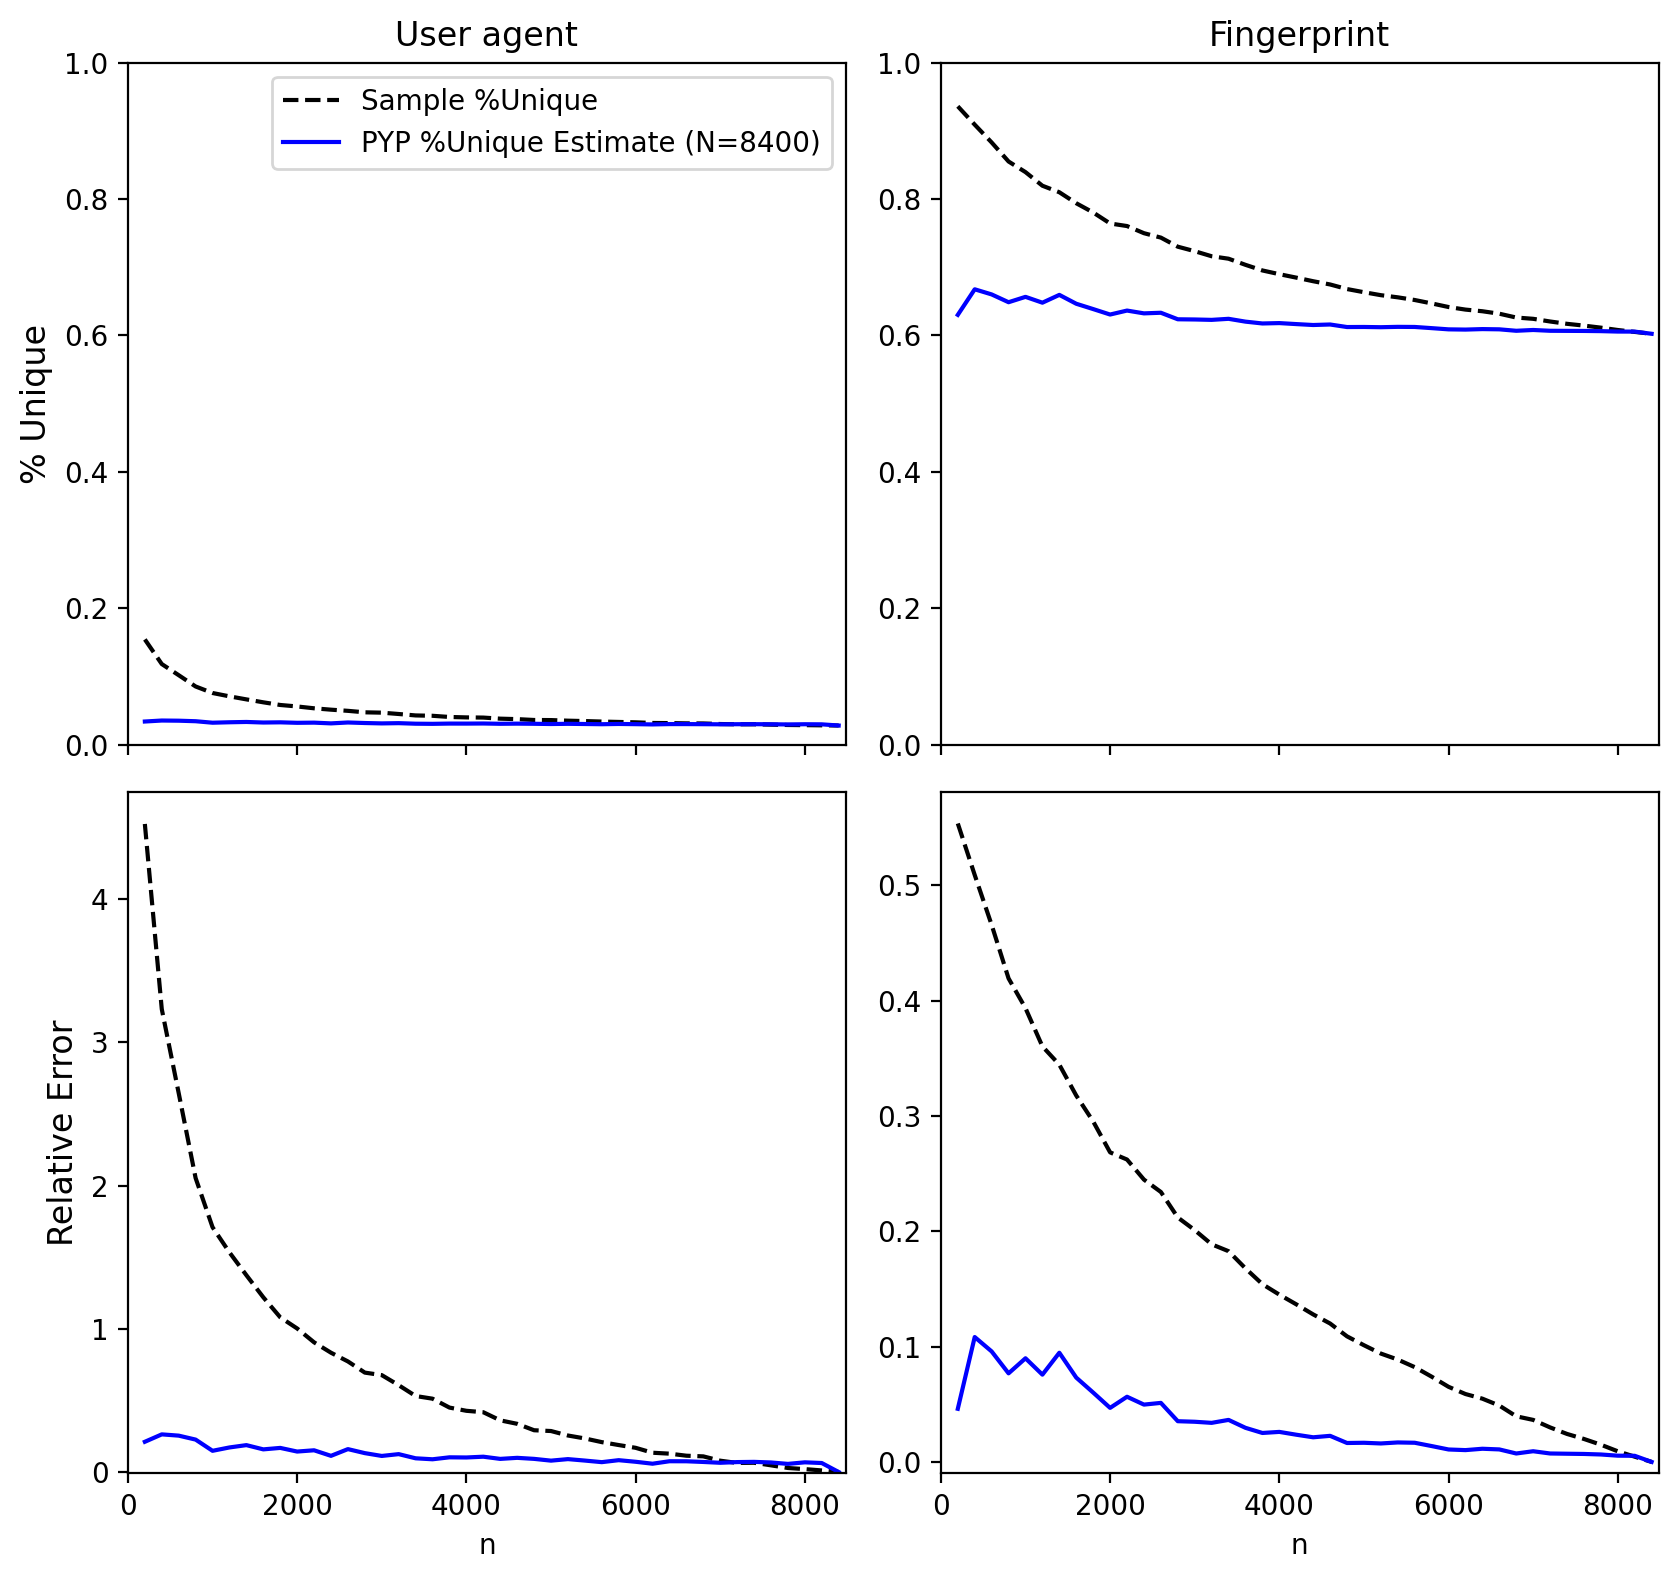

In [ ]:
# --- 3. Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(8.5, 8), dpi=200)

for i, attr in enumerate(attributes_to_plot):
    df_res = all_results[attr]

    # Plot 1: Absolute Estimates vs True Value (Top Row)
    ax1 = axes[0, i]
    ax1.plot(
        df_res.index,
        df_res['Naive % Unique'],
        label='Sample %Unique',
        color='black',
        linestyle='--'
    )
    ax1.plot(
        df_res.index,
        df_res['PYP Forecast % Unique'],
        label='PYP %Unique Estimate (N=8400)',
        color='blue'
    )

    # Set column titles
    ax1.set_title(attr)

    if i == 0:
        ax1.set_ylabel('% Unique', fontsize=12)
        ax1.legend()

    ax1.set_xlim(0, N_total * 1.01)
    ax1.set_ylim(0, 1)
    ax1.tick_params(labelbottom=False)

    # Plot 2: Relative Error (Bottom Row)
    ax2 = axes[1, i]
    ax2.plot(
        df_res.index,
        df_res['Naive % Unique_error'],
        label='Sample %Unique',
        color='black',
        linestyle='--'
    )
    ax2.plot(
        df_res.index,
        df_res['PYP Forecast % Unique_error'],
        label='PYP %Unique Estimate (N=8400)',
        color='blue'
    )

    ax2.set_xlabel('n')
    if i == 0:
        ax2.set_ylabel('Relative Error', fontsize=12)

    ax2.set_xlim(0, N_total * 1.01)

    # Add bounds safely in case of NaN
    max_err = max(
        df_res['Naive % Unique_error'].max(),
        df_res['PYP Forecast % Unique_error'].max()
    )
    ax2.set_ylim(-0.01, max_err * 1.05)

plt.tight_layout()
plt.show()

## Simulation of different distributions

Running synthetic distributions with PYP extrapolation...


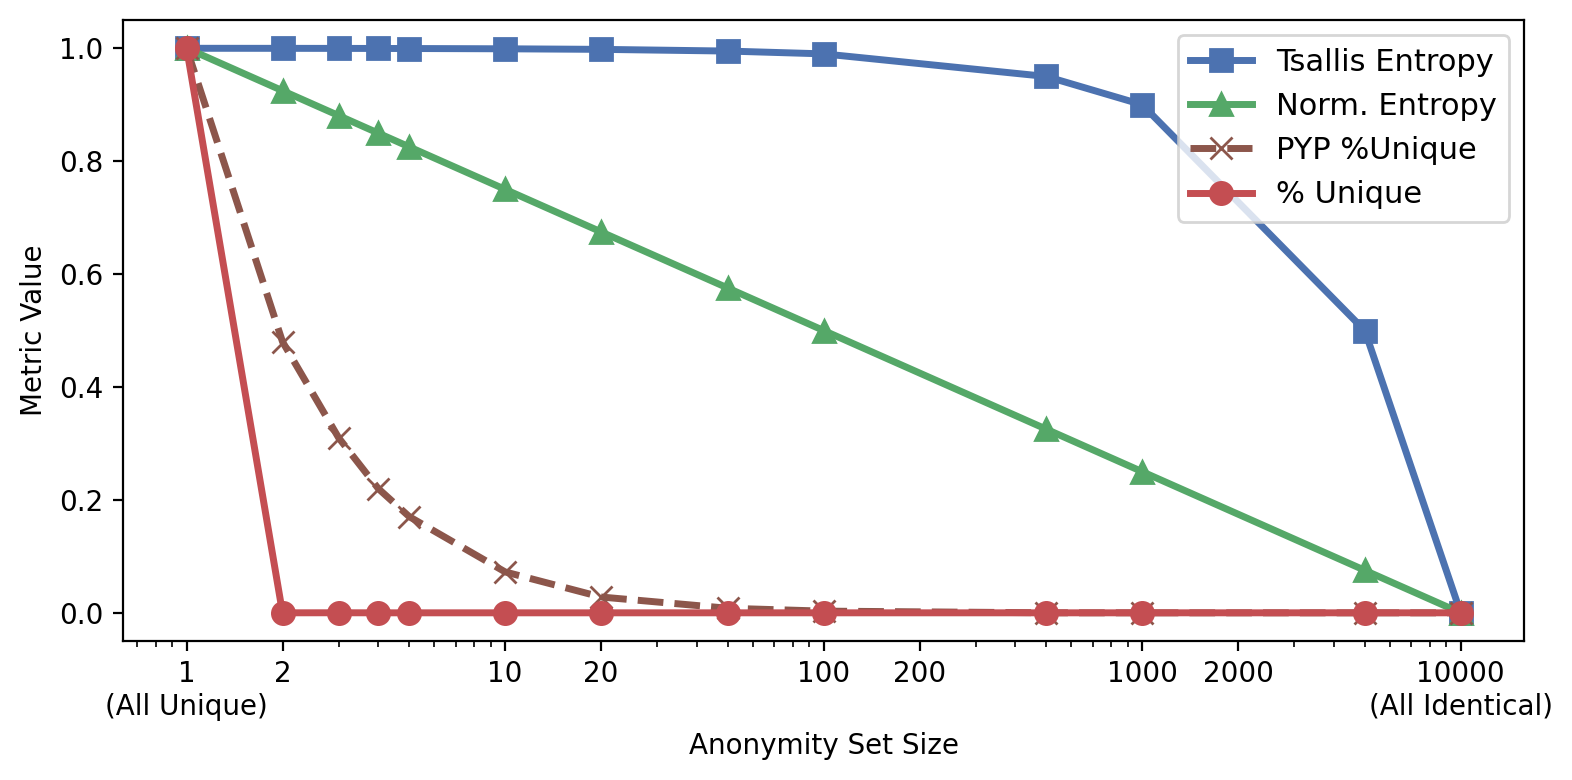

In [ ]:
from scipy.stats import entropy
N = 10000
# Test various anonymity set sizes:
# from completely unique (k=1) to completely identical (k=8400)
k_values = [1, 2, 3, 4, 5, 10, 20, 50, 100, 500, 1000, 5000, N]

results = []
training_n = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
trials = 30

print("Running synthetic distributions with PYP extrapolation...")

for k in k_values:
    # Create a synthetic distribution where everyone is in a group of size k
    num_groups = N // k
    dist = np.repeat(np.arange(num_groups), k)
    remainder = N % k
    if remainder > 0:
        dist = np.concatenate([dist, np.repeat(num_groups, remainder)])
    pk = pd.Series(dist).value_counts(normalize=True)

    # Calculate exact metrics
    frac_unique = (pk * len(dist) == 1).sum() / len(dist)
    tsallis = 1 - (pk**2).sum()

    # Normalize Shannon
    shannon = entropy(pk, base=2)
    norm_shannon = shannon / np.log2(N)

    # PYPExtrapolation forecast from small samples
    train_u = []
    for n in training_n:
        u_vals = [
            (pd.Series(
                np.random.choice(dist, size=n, replace=False)
            ).value_counts() == 1).sum() / n
            for _ in range(trials)
        ]
        train_u.append(np.mean(u_vals))

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = PYPExtrapolation(training_n, uniqueness=train_u)
            pyp_pred = model.predict([N])[0]
    except Exception:
        pyp_pred = np.nan

    results.append({
        'k': k,
        '% Unique': frac_unique,
        'PYP Forecast': pyp_pred,
        'Tsallis Entropy': tsallis,
        'Normalized Shannon': norm_shannon
    })

df_k = pd.DataFrame(results).set_index('k')

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 4), dpi=200)

ax.plot(
    df_k.index, df_k['Tsallis Entropy'], marker='s', markersize=8,
    linewidth=2.5, color='#4C72B0', label='Tsallis Entropy')
ax.plot(
    df_k.index, df_k['Normalized Shannon'], marker='^', markersize=8,
    linewidth=2.5, color='#55A868', label='Norm. Entropy')
ax.plot(
    df_k.index, df_k['PYP Forecast'], marker='x', markersize=8,
    linewidth=2.5, color='#8C564B', linestyle='--', label='PYP %Unique')
ax.plot(
    df_k.index, df_k['% Unique'], marker='o', markersize=8,
    linewidth=2.5, color='#C44E52', label='% Unique')

ax.set_xscale('log')
ax.set_xticks([1, 2, 10, 20, 100, 200, 1000, 2000, 10000])
ax.set_xticklabels(
    ['1\n(All Unique)', '2', '10', '20', '100',
     '200', '1000', '2000', '10000\n(All Identical)'])
ax.set_xlabel('Anonymity Set Size')
ax.set_ylabel('Metric Value')

ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()